In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, 
confusion_matrix, classification_report)

import skfuzzy as fuzz
import itertools

import joblib

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.shape

(768, 9)

In [7]:
df[['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']].describe()

,Glucose,BMI,Age,DiabetesPedigreeFunction
count,768.000000,768.000000,768.000000,768.000000
mean,120.894531,31.992578,33.240885,0.471876
std,31.972618,7.884160,11.760232,0.331329
min,0.000000,0.000000,21.000000,0.078000
25%,99.000000,27.300000,24.000000,0.243750
50%,117.000000,32.000000,29.000000,0.372500
75%,140.250000,36.600000,41.000000,0.626250
max,199.000000,67.100000,81.000000,2.420000


## Visualisasi awal target + fitur

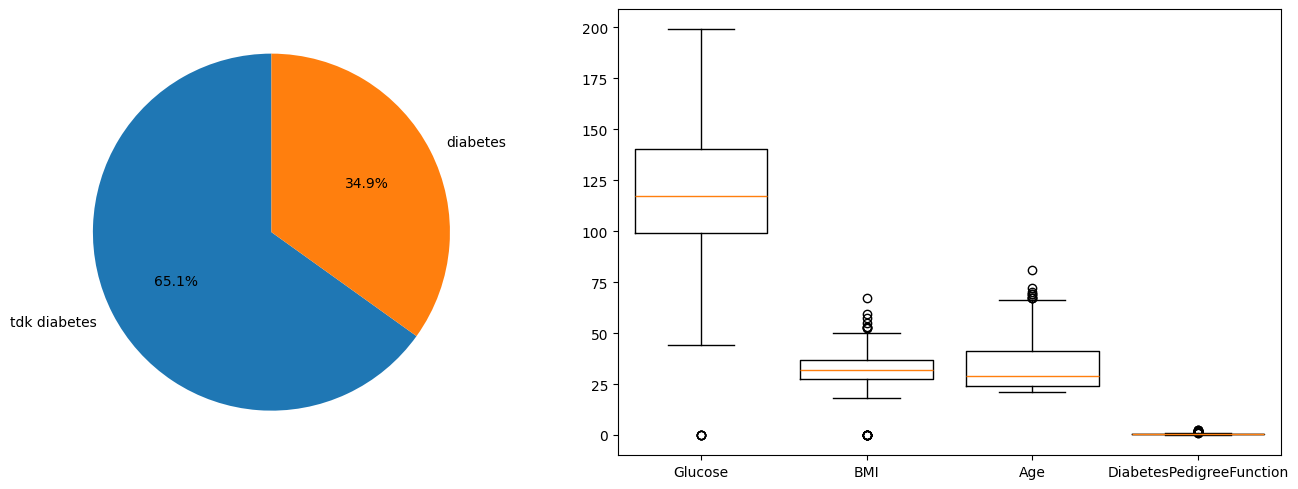

In [8]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
pie_count = df['Outcome'].value_counts()
axes[0].pie(pie_count, labels=['tdk diabetes', 'diabetes'], autopct='%1.1f%%', startangle=90)

# boxplot 4 fitur utama (Glucose, BMI, Age dan DiabetesPedigreeFunction)
boxplot1 = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
axes[1].boxplot(data=df, x=df[boxplot1], tick_labels=boxplot1, widths=0.8)

plt.tight_layout()
plt.show()

- dari dataset banyak mayoritas data pada yang tidak mengalami diabetes dengan proporsi niali 65.1% dan yang diabetes 34.9% (agak imbalance)
- Boxplot = terlihat kalau pada glucose dan BMI punya niali 0 jadi tidak realistis di dunia nyata dan harus melakukan imputasi(penghapusan missing value), utk DiabetesPedigreeFunction nilainya hanya 0-1 saja (mungkin dalam persen)

In [9]:
print(len(df[df['Glucose']==0]))
print(len(df[df['BMI']==0]))

5
11


In [10]:
# Penghapusan missing value karena hanya 16 baris aja atau sekitar 2% jadi aman
df = df[(df['Glucose'] != 0) & (df['BMI'] != 0)]

# Split data

In [11]:
fitur = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
X = df[fitur].values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisasi menggunakan MinMaxScaler

In [12]:
scaler = MinMaxScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

# menyimpan object scaler yg sudha di latih
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [13]:
# cek statistika nilai setealh scaler
X_scaler_vis = scaler.transform(X)
df_scaled = pd.DataFrame(X_scaler_vis, columns=fitur)

df_scaled.describe()

,Glucose,BMI,Age,DiabetesPedigreeFunction
count,752.000000,752.000000,752.000000,752.000000
mean,0.506114,0.291506,0.205208,0.166546
std,0.198709,0.141696,0.195157,0.141313
min,0.000000,0.000000,0.000000,-0.002568
25%,0.362013,0.190184,0.050000,0.068493
50%,0.474026,0.288344,0.133333,0.125428
75%,0.629870,0.376278,0.333333,0.232663
max,1.006494,1.000000,1.000000,1.000000


# ANFIS LAYER 1

- Pada tahap ini akan mendifinisikan kategory fuzzy(membership function) seperti `low / medium / high` yg sudah di normalisai

## Membuat paramter MF berbasis sumber valid

In [14]:
# rentang nilai continue utk plot membership function fuzzy
x_universe = np.linspace(0, 1, 500)

# kita buat dlm dictionary
mf_param = {
    'Glucose': { # dari diabetes.org/about-diabetes/diagnosis (American Diabetes Association)
        'Low'    : (0.20, 0.15),
        'Medium' : (0.50, 0.18),
        'High'   : (0.80, 0.15),
    },
    'BMI' : { # who.int/news-room/fact-sheets/detail/obesity-and-overweight(WHO)
        'Low'    : (0.15, 0.12),
        'Medium' : (0.40, 0.18),
        'High'   : (0.70, 0.18),
    },
    'Age' : { # berdasarkan nilai stastitika
        'Low'    : (0.15, 0.18),
        'Medium' : (0.45, 0.22),
        'High'   : (0.80, 0.18),
    },
    'DiabetesPedigreeFunction' : { # berdasarkan nilai stastitika
        'Low'    : (0.10, 0.12),
        'Medium' : (0.35, 0.20),
        'High'   : (0.70, 0.20),
    },
}

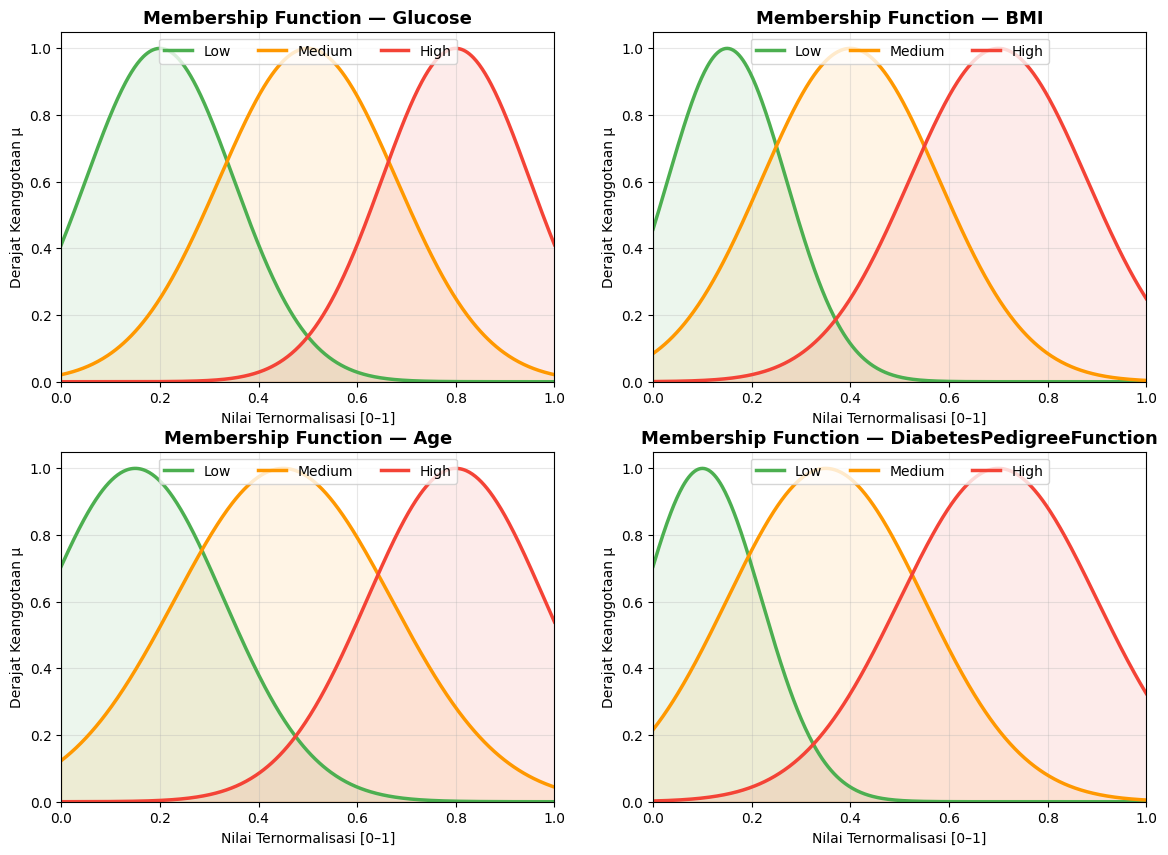

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
MF_COLORS = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

for idx, feat in enumerate(fitur):
    ax = axes[idx]
    for label, (center, sigma) in mf_param[feat].items():
        mf_vals = fuzz.gaussmf(x_universe, center, sigma)
        ax.plot(x_universe, mf_vals, label=label,
                color=MF_COLORS[label], linewidth=2.5)
        ax.fill_between(x_universe, mf_vals, alpha=0.10, color=MF_COLORS[label])
    ax.set_title(f'Membership Function — {feat}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Nilai Ternormalisasi [0–1]')
    ax.set_ylabel('Derajat Keanggotaan μ')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.legend(loc='upper center', ncol=3, fontsize=10)
    ax.grid(True, alpha=0.3)

# Implementasi Algoritma Anfis

In [16]:
# class blueprint ANFIS
class ANFIS:
    def __init__(self, n_mf=3, epochs=200, lr_premise=0.005,
                 l2_lambda=1e-4, patience=30):
        self.n_mf        = n_mf
        self.epochs      = epochs
        self.lr_premise  = lr_premise
        self.l2_lambda   = l2_lambda
        self.patience    = patience
        self.loss_hist   = []
        self._is_fitted  = False

# Proses Fuzzification
    def _gaussmf(self, x, c, sigma):
        return np.exp(-0.5 * ((x - c) / (sigma + 1e-8)) ** 2) # rumus gaussian mf

# Proses Rule (utk menghitung seberapa kuat dari kombinasi role yg ada)
    def _rule_strength(self, mu):
        # inputan nantinya mu: (n_samples, n_inputs, n_mf) → (n_samples, n_rules)
        n = mu.shape[0]
        strengths = np.ones((n, self.n_rules))
        for r, combo in enumerate(self.rule_combos):
            mu_stack = np.stack(
                [mu[:, i, mf_idx] for i, mf_idx in enumerate(combo)],
                axis=1)
            strengths[:, r] = mu_stack.min(axis=1)
        return strengths

# Proses Normalisasi -> mengubah hasil role tdi mejadi bobot relatif (kontribusi)
    def _normalize(self, strengths):
        total = strengths.sum(axis=1, keepdims=True) + 1e-8
        return strengths / total

# proses Consequent 
    def _sigmoid(self, x):
        return np.where(x >= 0,
                        1 / (1 + np.exp(-x)),
                        np.exp(x) / (1 + np.exp(x)))
        
# membuat matriks desain Phi utk Least Square Estimation (LSE)
    def _build_phi(self, X, w_norm):
        n_samples, n_inputs = X.shape
        X_aug = np.hstack([X, np.ones((n_samples, 1))])  # (n, n_inputs+1)
        Phi   = np.zeros((n_samples, self.n_rules * (n_inputs + 1))) # wadah kosong
        for r in range(self.n_rules):
            start = r * (n_inputs + 1) # 0,4 -> R1
            end   = start + (n_inputs + 1) 
            Phi[:, start:end] = w_norm[:, r:r+1] * X_aug
        return Phi

    # Mencari paramter consequent C terbaik 
    def _lse_solve(self, Phi, y):
        n_params = Phi.shape[1]
        # Ridge regression (regularized LSE)
        A      = Phi.T @ Phi + self.l2_lambda * np.eye(n_params)
        b      = Phi.T @ y.astype(np.float64)
        C_flat = np.linalg.solve(A, b)  # lebih stabil dari inv()
        return C_flat.reshape(self.n_rules, -1)

# --------> FORWARD PASS -------------

    def _forward(self, X):
        # LAYER 1 Fuzzifucation
        n_samples, n_inputs = X.shape
        mu = np.zeros((n_samples, n_inputs, self.n_mf))
        for i in range(n_inputs):
            for k in range(self.n_mf):
                mu[:, i, k] = self._gaussmf(
                    X[:, i], self.centers[i, k], self.sigmas[i, k])
                
        # Layer 2 Rule Layer
        strengths = self._rule_strength(mu)
        
        #Layer 3 : Normalisasi
        w_norm    = self._normalize(strengths)
        
        # Layer 4 CONSEQUENT
        X_aug     = np.hstack([X, np.ones((n_samples, 1))])
        consequents = X_aug @ self.C.T  # (n, n_rules), --> Output sebelum sigmoid (raw/linear)

        # Layer 5 Output
        raw         = (w_norm * consequents).sum(axis=1)
        output      = self._sigmoid(raw)
        return output, raw, w_norm, strengths, mu

    def _compute_loss(self, output, y):
        eps        = 1e-8
        n_neg      = (y == 0).sum()
        n_pos      = (y == 1).sum()
        pos_weight = n_neg / (n_pos + 1e-8)
        bce = -np.mean(
            pos_weight * y * np.log(output + eps) +
            (1 - y) * np.log(1 - output + eps)
        )
        return bce

# --------> FIT -------------
    def fit(self, X, y):
        n_samples, n_inputs = X.shape
        self.n_inputs = n_inputs

        # kita generate semua kombinasi rule 
        self.rule_combos = list(itertools.product(range(self.n_mf), repeat=n_inputs))
        self.n_rules = len(self.rule_combos)

        # center dan sigmanya berdasarkan nilai pada dictionary yang sudah di tentukan
        labels = ['Low', 'Medium', 'High']

        # INISIAL
        # utk center
        self.centers = np.array([
            [mf_param[feat][lbl][0] for lbl in labels] 
            for feat in fitur 
        ])

        # utk sigma 
        self.sigmas = np.array([
            [mf_param[feat][lbl][1] for lbl in labels]
            for feat in fitur
        ])

        # Inisialisasi C awal linear Sugeno
        self.C = np.zeros((self.n_rules, n_inputs + 1))
        
        print(f"Input    : {n_inputs} fitur | Rules: {self.n_rules}")
        print(f"Metode C : Least Squares Estimator (eksak)")
        print(f"Metode MF: Gradient Descent")
        print(f"Epochs   : {self.epochs} | LR premise: {self.lr_premise}")
        print("-" * 60)

        # simpan model terbaik 
        best_loss  = np.inf
        best_C     = self.C.copy()
        best_ctr   = self.centers.copy()
        best_sig   = self.sigmas.copy()
        no_improve = 0

        for epoch in range(self.epochs):

            # FASE 1 — FORWARD: hitung mu, w_norm, Phi
            n_samples, n_inputs = X.shape
            mu = np.zeros((n_samples, n_inputs, self.n_mf))
            for i in range(n_inputs):
                for k in range(self.n_mf):
                    mu[:, i, k] = self._gaussmf(
                        X[:, i], self.centers[i, k], self.sigmas[i, k])
            strengths = self._rule_strength(mu)
            w_norm    = self._normalize(strengths)

            # FASE 2 — LSE: update C secara eksak
            # Ini inti hybrid learning — 
            Phi    = self._build_phi(X, w_norm)
            self.C = self._lse_solve(Phi, y)

            # Hitung output & loss setelah C diupdate
            X_aug       = np.hstack([X, np.ones((n_samples, 1))])
            consequents = X_aug @ self.C.T # Taki-Sugeno Linear
            raw         = (w_norm * consequents).sum(axis=1)
            output      = self._sigmoid(raw)
            loss        = self._compute_loss(output, y)
            self.loss_hist.append(loss)

            # Best state
            if loss < best_loss - 1e-6:
                best_loss = loss
                best_C    = self.C.copy()
                best_ctr  = self.centers.copy()
                best_sig  = self.sigmas.copy()
                no_improve = 0
            else:
                no_improve += 1

            # FASE 3 — BACKWARD: update premise aja
            delta = output - y

            # memperbaiki premise parameter w_norm
            consequents_val = X_aug @ self.C.T
            d_loss_d_wnorm  = (delta / n_samples)[:, None] * consequents_val

            # Gradient normalisasi
            total_s      = strengths.sum(axis=1, keepdims=True) + 1e-8
            sum_weighted = (d_loss_d_wnorm * strengths).sum(axis=1, keepdims=True)
            d_loss_d_str = (d_loss_d_wnorm * total_s - sum_weighted) / (total_s ** 2)

            # Gradient ke mu (minimum T-norm)
            d_loss_d_mu = np.zeros_like(mu)
            for r, combo in enumerate(self.rule_combos):
                mu_stack = np.stack(
                    [mu[:, i, mf_idx] for i, mf_idx in enumerate(combo)],
                    axis=1)
                min_idx = mu_stack.argmin(axis=1)
                for s_idx in range(n_samples):
                    active_i  = min_idx[s_idx]
                    active_mf = combo[active_i]
                    d_loss_d_mu[s_idx, active_i, active_mf] += \
                        d_loss_d_str[s_idx, r]

            # Update centers & sigmas
            for i in range(n_inputs):
                for k in range(self.n_mf):
                    x_col  = X[:, i]
                    c_ik   = self.centers[i, k]
                    sig_ik = self.sigmas[i, k] + 1e-8
                    mu_ik  = mu[:, i, k]

                    d_mu_d_c   = mu_ik * (x_col - c_ik) / (sig_ik ** 2)
                    d_mu_d_sig = mu_ik * ((x_col - c_ik) ** 2) / (sig_ik ** 3)

                    grad_c   = np.clip(
                        np.mean(d_loss_d_mu[:, i, k] * d_mu_d_c),   -0.5, 0.5)
                    grad_sig = np.clip(
                        np.mean(d_loss_d_mu[:, i, k] * d_mu_d_sig), -0.5, 0.5)

                    self.centers[i, k] -= self.lr_premise * grad_c
                    self.sigmas[i, k]  -= self.lr_premise * grad_sig
                    self.sigmas[i, k]   = np.clip(self.sigmas[i, k], 0.02, 0.5)

            # Early stopping
            if epoch > 20 and no_improve >= self.patience:
                print(f"Early stopping epoch {epoch+1}")
                break

            # monitoring loss 
            if (epoch + 1) % 20 == 0 or epoch == 0:
                acc = accuracy_score(y, (output >= 0.5).astype(int))
                print(f"Epoch [{epoch+1:>4}/{self.epochs}]  "
                      f"Loss: {loss:.5f}  Acc: {acc:.4f}")

        self.C       = best_C
        self.centers = best_ctr
        self.sigmas  = best_sig
        self._is_fitted = True
        print("-" * 60)
        print(f"Selesai. Best loss: {best_loss:.5f}")
        return self

    def predict_proba(self, X):
        assert self._is_fitted
        output, _, _, _, _ = self._forward(X)
        return output

    # prediksi 
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    # # Membuat derajat keanggotaan untuk interpretabilitas
    # def get_membership(self, x_single):
    #     labels = ['Low', 'Medium', 'High']
    #     result = {}
    #     for i, feat in enumerate(fitur):
    #         result[feat] = {
    #             lbl: float(self._gaussmf(
    #                 x_single[i], self.centers[i, k], self.sigmas[i, k]))
    #             for k, lbl in enumerate(labels)
    #         }
    #     return result

In [17]:
anfis = ANFIS(
    n_mf        = 3,
    epochs      = 200,
    lr_premise  = 0.005,
    l2_lambda   = 1e-4,
    patience    = 30,
)
anfis.fit(X_train_scaler, y_train)

Input    : 4 fitur | Rules: 81
Metode C : Least Squares Estimator (eksak)
Metode MF: Gradient Descent
Epochs   : 200 | LR premise: 0.005
------------------------------------------------------------
Epoch [   1/200]  Loss: 0.77123  Acc: 0.4809
Epoch [  20/200]  Loss: 0.77122  Acc: 0.4809
Epoch [  40/200]  Loss: 0.77122  Acc: 0.4825
Epoch [  60/200]  Loss: 0.77121  Acc: 0.4809
Epoch [  80/200]  Loss: 0.77120  Acc: 0.4809
Epoch [ 100/200]  Loss: 0.77119  Acc: 0.4792
Epoch [ 120/200]  Loss: 0.77118  Acc: 0.4792
Epoch [ 140/200]  Loss: 0.77117  Acc: 0.4792
Epoch [ 160/200]  Loss: 0.77116  Acc: 0.4792
Epoch [ 180/200]  Loss: 0.77115  Acc: 0.4809
Epoch [ 200/200]  Loss: 0.77114  Acc: 0.4809
------------------------------------------------------------
Selesai. Best loss: 0.77114


# Evaluasi model

In [18]:
y_pred_train = anfis.predict(X_train_scaler)
y_pred_test  = anfis.predict(X_test_scaler)
y_proba_test = anfis.predict_proba(X_test_scaler)

def print_metrics(y_true, y_pred, split_name="Test"):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'='*50}")
    print(f"  HASIL EVALUASI — {split_name} Set")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

acc_tr, prec_tr, rec_tr, f1_tr = print_metrics(y_train, y_pred_train, "Training")
acc_te, prec_te, rec_te, f1_te = print_metrics(y_test,  y_pred_test,  "Testing")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test,
      target_names=['Non-Diabetes', 'Diabetes']))


  HASIL EVALUASI — Training Set
  Accuracy  : 0.4809  (48.09%)
  Precision : 0.4034
  Recall    : 1.0000
  F1-Score  : 0.5749

  HASIL EVALUASI — Testing Set
  Accuracy  : 0.5298  (52.98%)
  Precision : 0.4262
  Recall    : 0.9811
  F1-Score  : 0.5943

Classification Report (Test Set):
              precision    recall  f1-score   support

Non-Diabetes       0.97      0.29      0.44        98
    Diabetes       0.43      0.98      0.59        53

    accuracy                           0.53       151
   macro avg       0.70      0.63      0.52       151
weighted avg       0.78      0.53      0.49       151



In [19]:
# ============================================================
# CELL: Hitung threshold adaptif dari distribusi output model
# Jalankan SEBELUM export pkl
# ============================================================

y_proba_train = anfis.predict_proba(X_train_scaler)
y_proba_test  = anfis.predict_proba(X_test_scaler)
y_proba_all   = np.concatenate([y_proba_train, y_proba_test])

# Persentil 33 dan 66 sebagai batas LOW/MEDIUM/HIGH
p33 = float(np.percentile(y_proba_all, 33))
p66 = float(np.percentile(y_proba_all, 66))

print(f"Min output   : {y_proba_all.min():.4f}")
print(f"Max output   : {y_proba_all.max():.4f}")
print(f"Threshold P33: {p33:.4f}  → batas LOW / MEDIUM")
print(f"Threshold P66: {p66:.4f}  → batas MEDIUM / HIGH")

# Simpan threshold bersama model
joblib.dump({'model': anfis, 'scaler': scaler,
             'thresh_low': p33, 'thresh_high': p66},
            'anfis_bundle.pkl')

print("\n✅ Bundle tersimpan: anfis_bundle.pkl")
print("   Gunakan file ini di app.py (ganti anfis_model.pkl + scaler.pkl)")

Min output   : 0.4038
Max output   : 0.7948
Threshold P33: 0.5240  → batas LOW / MEDIUM
Threshold P66: 0.6119  → batas MEDIUM / HIGH

✅ Bundle tersimpan: anfis_bundle.pkl
   Gunakan file ini di app.py (ganti anfis_model.pkl + scaler.pkl)
